In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df=pd.read_csv("Global_Sports_Footwear_sales_2018_2026_Dataset.csv")

Checking if the data is not clean

In [13]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,...,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating,Year,Discount_Band,ASP
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,...,1,137.7,Card,Retail Store,Germany,Low,4.6,2021,11-20%,137.70
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,...,3,228.0,Card,Online,USA,Low,3.9,2026,0-10%,76.00
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,...,4,598.4,Cash,Retail Store,India,Medium,3.0,2023,11-20%,149.60
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,...,2,103.7,Card,Retail Store,India,High,3.4,2026,11-20%,51.85
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,...,4,320.0,Cash,Online,USA,Medium,3.0,2019,0-10%,80.00


In [10]:
df.isnull().sum()

order_id                 0
order_date               0
brand                    0
model_name               0
category                 0
gender                   0
size                     0
color                    0
base_price_usd           0
discount_percent         0
final_price_usd          0
units_sold               0
revenue_usd              0
payment_method           0
sales_channel            0
country                  0
customer_income_level    0
customer_rating          0
dtype: int64

In [14]:
df.duplicated().sum()


np.int64(0)

In [16]:
df['calculated_revenue']=df['final_price_usd']*df['units_sold']
revenue_mismatch = df[
    np.abs(df['calculated_revenue']-df['revenue_usd'])>0.01
]
print("Number of revenue mismatches:",len(revenue_mismatch))

Number of revenue mismatches: 0


In [17]:
df.drop(columns=["calculated_revenue"],inplace=True)

So, yeah there is no missing value , no duplicates , no incosistent values in revenue_usd column.....Hence,Data is already clean:-)

Now, its time for feature engineering <--Important 

Extracting year after converting date into required format

In [3]:
df["order_date"]=pd.to_datetime(df["order_date"])

In [4]:
df["Year"]=df["order_date"].dt.year

Create Discount Band and  make it ordered....reason is not clear to me also till now but as far as i can understand is that it is done to make graphs correctly 

In [5]:
def create_discount_band(x):
    if x<=10:
        return "0-10%"
    elif x<=20:
        return "11-20%"
    else:
        return "21-30%"

In [6]:
df["Discount_Band"]=df["discount_percent"].apply(create_discount_band)

In [7]:
discount_order = ["0-10%","11-20%","21-30%"]
df["Discount_Band"]=pd.Categorical(df["Discount_Band"],categories=discount_order,ordered=True)

Creating Average Selling Price by dividing revenue generated by number of units sold.....makes sense

In [8]:
df["ASP"]=df["revenue_usd"]/df["units_sold"]

Just knowing total revenue for future use

In [9]:
total_revenue = df["revenue_usd"].sum()

In [10]:
print(total_revenue)

9081448.45


Lets do some real analysis

Created brand wise summary and including their revenue share 

In [37]:
brand_summary = df.groupby("brand").agg(
    Total_Revenue = ("revenue_usd","sum"),
    Total_Units = ("units_sold","sum"),
    Avg_Discount = ("discount_percent","mean"),
    Avg_ASP = ("ASP","mean"),
    Avg_Satisfaction = ("customer_rating","mean")
).reset_index()

In [38]:
brand_summary["Revenue_Share_%"]=(
    brand_summary["Total_Revenue"]/total_revenue*100
)

In [43]:
brand_summary.sort_values(by="Total_Revenue",ascending=False)

,brand,Total_Revenue,Total_Units,Avg_Discount,Avg_ASP,Avg_Satisfaction,Revenue_Share_%
0,ASICS,1561462.50,12874,13.302806,121.281713,4.008944,17.193981
3,Nike,1524582.10,12481,13.190514,121.470347,3.998366,16.787874
2,New Balance,1511401.50,12541,13.269771,120.725251,3.998434,16.642736
4,Puma,1499094.90,12315,13.539805,121.361119,4.002600,16.507222
5,Reebok,1498640.90,12469,13.218265,120.475209,4.012396,16.502223
1,Adidas,1486266.55,12326,13.479057,120.856314,3.988064,16.365964


Detecting Pricing power by comparing Average asp and average discount

In [44]:
brand_summary.sort_values(by="Avg_ASP",ascending=False)

,brand,Total_Revenue,Total_Units,Avg_Discount,Avg_ASP,Avg_Satisfaction,Revenue_Share_%
3,Nike,1524582.10,12481,13.190514,121.470347,3.998366,16.787874
4,Puma,1499094.90,12315,13.539805,121.361119,4.002600,16.507222
0,ASICS,1561462.50,12874,13.302806,121.281713,4.008944,17.193981
1,Adidas,1486266.55,12326,13.479057,120.856314,3.988064,16.365964
2,New Balance,1511401.50,12541,13.269771,120.725251,3.998434,16.642736
5,Reebok,1498640.90,12469,13.218265,120.475209,4.012396,16.502223


In [45]:
brand_summary.sort_values(by="Avg_Discount",ascending=False)

,brand,Total_Revenue,Total_Units,Avg_Discount,Avg_ASP,Avg_Satisfaction,Revenue_Share_%
4,Puma,1499094.90,12315,13.539805,121.361119,4.002600,16.507222
1,Adidas,1486266.55,12326,13.479057,120.856314,3.988064,16.365964
0,ASICS,1561462.50,12874,13.302806,121.281713,4.008944,17.193981
2,New Balance,1511401.50,12541,13.269771,120.725251,3.998434,16.642736
5,Reebok,1498640.90,12469,13.218265,120.475209,4.012396,16.502223
3,Nike,1524582.10,12481,13.190514,121.470347,3.998366,16.787874


Analyzing Discount vs Satisfaction

In [ ]:
df.groupby("brand")[["discount_percent","customer_rating"]].corr()

discount_percent  customer_rating
brand                                                          
ASICS       discount_percent          1.000000         0.006164
            customer_rating           0.006164         1.000000
Adidas      discount_percent          1.000000        -0.003896
            customer_rating          -0.003896         1.000000
New Balance discount_percent          1.000000         0.010632
            customer_rating           0.010632         1.000000
Nike        discount_percent          1.000000        -0.013925
            customer_rating          -0.013925         1.000000
Puma        discount_percent          1.000000         0.013239
            customer_rating           0.013239         1.000000
Reebok      discount_percent          1.000000        -0.007602
            customer_rating          -0.007602         1.000000

or other way

In [50]:
brand_corr = df.groupby("brand").apply(
    lambda x: x["discount_percent"].corr(
        x["customer_rating"]
    )
).reset_index(name="Discount_Satisfaction_Correlation")

brand_corr


C:\Users\HP\AppData\Local\Temp\ipykernel_468\2346252346.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  brand_corr = df.groupby("brand").apply(


,brand,Discount_Satisfaction_Correlation
0,ASICS,0.006164
1,Adidas,-0.003896
2,New Balance,0.010632
3,Nike,-0.013925
4,Puma,0.013239
5,Reebok,-0.007602


Checking revenue growth trend

In [51]:
brand_year = df.groupby(["Year","brand"])["revenue_usd"].sum().reset_index()

In [59]:
brand_pivot = brand_year.pivot(index="Year",columns="brand",values="revenue_usd")

In [53]:
brand_pivot

brand,ASICS,Adidas,New Balance,Nike,Puma,Reebok
Year,,,,,,
2018,171409.20,161008.75,164622.35,178398.90,159711.55,155229.45
2019,191287.40,164494.05,167195.75,166007.75,174878.00,165865.20
2020,188520.90,175219.80,170818.10,162657.40,163565.95,171563.60
2021,158468.50,168434.50,162984.90,159822.70,169961.30,166393.75
2022,164804.40,160135.60,182219.95,173576.85,180276.05,165647.05
2023,173091.60,170117.25,162278.80,177603.85,165866.65,176177.75
2024,179101.05,158582.15,164757.50,160794.30,153283.10,153521.15
2025,165008.25,172882.10,182247.80,170818.15,164237.95,168902.60
2026,169771.20,155392.35,154276.35,174902.20,167314.35,175340.35


In [56]:
brand_growth = brand_pivot.pct_change() * 100
brand_growth

brand,ASICS,Adidas,New Balance,Nike,Puma,Reebok
Year,,,,,,
2018,NaN,NaN,NaN,NaN,NaN,NaN
2019,11.596927,2.164665,1.563214,-6.945755,9.496151,6.851632
2020,-1.446253,6.520449,2.166532,-2.018189,-6.468538,3.435561
2021,-15.941150,-3.872450,-4.585697,-1.742743,3.909952,-3.013372
2022,3.998208,-4.927078,11.801737,8.605880,6.068882,-0.448755
2023,5.028507,6.233249,-10.943450,2.320010,-7.992964,6.357312
2024,3.471832,-6.780676,1.527433,-9.464632,-7.586546,-12.860080
2025,-7.868631,9.017377,10.615784,6.233959,7.146809,10.019108
2026,2.886492,-10.116577,-15.348032,2.390876,1.873136,3.811516


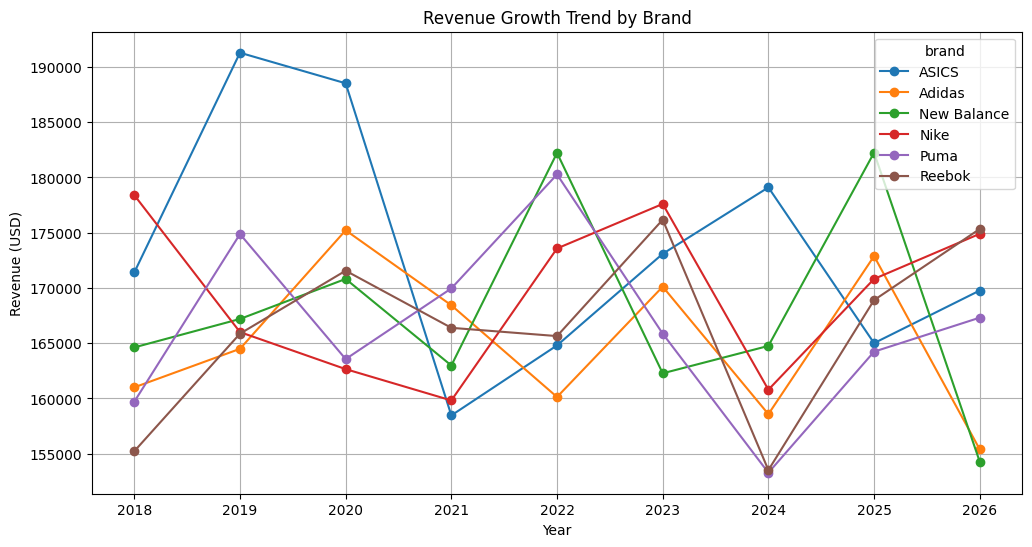

In [60]:
brand_pivot.plot(figsize=(12,6), marker="o")

plt.title("Revenue Growth Trend by Brand")
plt.ylabel("Revenue (USD)")
plt.xlabel("Year")
plt.grid(True)

plt.show()


Discount Startegy Effectiveness

In [12]:
discount_summary = df.groupby("Discount_Band").agg(
    Total_Revenue = ("revenue_usd","sum"),
    Total_Units = ("units_sold","sum"),
    Avg_ASP = ("ASP","mean"),
    Avg_Discount=("discount_percent","mean"),
    Avg_Satisfaction=("customer_rating","mean")
).reset_index()
total_revenue = df["revenue_usd"].sum()

discount_summary["Revenue_Share_%"] = (
    discount_summary["Total_Revenue"] / total_revenue * 100
)

discount_summary

C:\Users\HP\AppData\Local\Temp\ipykernel_9152\1227919361.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_summary = df.groupby("Discount_Band").agg(


,Discount_Band,Total_Revenue,Total_Units,Avg_ASP,Avg_Discount,Avg_Satisfaction,Revenue_Share_%
0,0-10%,4984108.65,37541,132.777355,5.004989,4.000512,54.882310
1,11-20%,2871210.00,24894,115.169316,17.527853,4.004376,31.616212
2,21-30%,1226129.80,12571,97.394443,30.000000,3.999001,13.501478


Units Sold by Discount Band

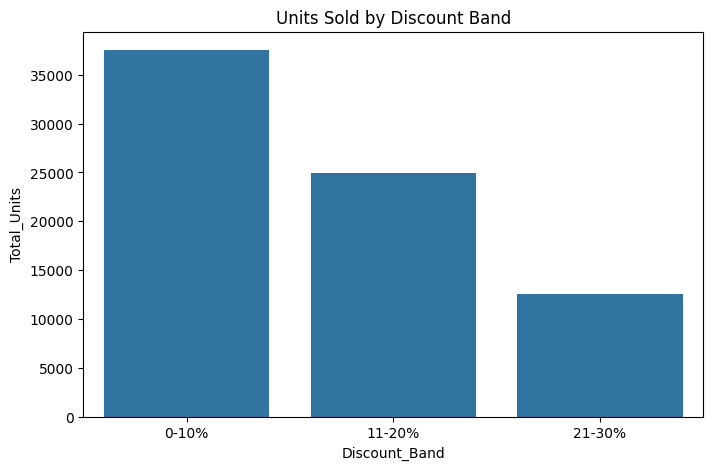

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=discount_summary,
            x="Discount_Band",
            y="Total_Units")

plt.title("Units Sold by Discount Band")
plt.show()

Building Channel Strategy(Online vs Retail)

Channel Summary

In [16]:
channel_summary = df.groupby("sales_channel").agg(
    Total_Revenue=("revenue_usd","sum"),
    Total_Units = ("units_sold","sum"),
    Avg_ASP=("ASP","mean"),
    Avg_Discount=("discount_percent","mean"),
    Avg_Satisfaction=("customer_rating","mean")
).reset_index()

In [17]:
channel_summary["Revenue_Share_%"]=(
    channel_summary["Total_Revenue"]/total_revenue*100
)
channel_summary

,sales_channel,Total_Revenue,Total_Units,Avg_ASP,Avg_Discount,Avg_Satisfaction,Revenue_Share_%
0,Online,4540629.20,37527,120.855994,13.419051,3.998139,49.998954
1,Retail Store,4540819.25,37479,121.201869,13.245386,4.004944,50.001046


Brand wise Channel Analysis

In [20]:
brand_channel  = df.groupby(["brand","sales_channel"]).agg(
    Revenue = ("revenue_usd","sum"),
    Avg_Discount = ("discount_percent","mean"),
    Avg_ASP = ("ASP","mean")
).reset_index()



In [21]:
brand_channel

,brand,sales_channel,Revenue,Avg_Discount,Avg_ASP
0,ASICS,Online,773546.40,13.447937,120.801650
1,ASICS,Retail Store,787916.10,13.160031,121.753981
2,Adidas,Online,749047.15,13.587000,120.745478
3,Adidas,Retail Store,737219.40,13.369521,120.968783
4,New Balance,Online,747022.40,13.337379,120.132261
5,New Balance,Retail Store,764379.10,13.203187,121.309263
6,Nike,Online,782138.25,13.164779,121.562573
7,Nike,Retail Store,742443.85,13.217338,121.374217
8,Puma,Online,735290.00,13.719737,121.332150
9,Puma,Retail Store,763804.90,13.363490,121.389505


Geographic Market Prioritization

Country wise Summary

In [23]:
country_summary = df.groupby("country").agg(
    Total_Revenue=("revenue_usd", "sum"),
    Total_Units=("units_sold", "sum"),
    Avg_ASP=("ASP", "mean"),
    Avg_Discount=("discount_percent", "mean"),
    Avg_Satisfaction=("customer_rating", "mean")
).reset_index()

In [24]:
country_summary["Revenue_Share_%"] = (
    country_summary["Total_Revenue"] / total_revenue * 100
)

In [25]:
country_summary.sort_values(by="Total_Revenue", ascending=False)

,country,Total_Revenue,Total_Units,Avg_ASP,Avg_Discount,Avg_Satisfaction,Revenue_Share_%
3,UAE,1546442.55,12818,120.984965,13.390973,4.008832,17.028589
4,UK,1532300.05,12662,121.063019,13.571570,4.004784,16.872860
1,India,1520898.95,12539,120.973572,13.396113,3.998437,16.747317
5,USA,1511747.45,12472,121.375701,13.347921,3.990113,16.646546
0,Germany,1503894.85,12452,120.646002,13.117825,4.000584,16.560077
2,Pakistan,1466164.60,12063,121.130159,13.157405,4.006507,16.144612


In [ ]:
country_income = pd.crosstab(df['country'], df['customer_income_level'])
country_income

customer_income_level,High,Low,Medium
country,,,
Germany,1656,1675,1634
India,1699,1695,1597
Pakistan,1663,1576,1602
UAE,1688,1633,1797
UK,1667,1726,1665
USA,1686,1639,1702


Behavior by Income

In [32]:
income_summary = df.groupby('customer_income_level').agg({
    'ASP':'mean',
    'discount_percent':'mean',
    'units_sold':'mean',
    'customer_rating':'mean'
}).reset_index()

income_summary


,customer_income_level,ASP,discount_percent,units_sold,customer_rating
0,High,120.553554,13.351228,2.504822,3.997137
1,Low,121.855727,13.245676,2.510660,4.000553
2,Medium,120.685156,13.399020,2.485146,4.006962


In [33]:
pd.crosstab(df['customer_income_level'], df['brand'])

brand,ASICS,Adidas,New Balance,Nike,Puma,Reebok
customer_income_level,,,,,,
High,1685,1634,1708,1727,1627,1678
Low,1744,1662,1647,1594,1649,1648
Medium,1703,1622,1627,1697,1648,1700


Country wise channel analysis

In [26]:
country_channel = df.groupby(
    ["country", "sales_channel"]
)["revenue_usd"].sum().reset_index()

country_channel

,country,sales_channel,revenue_usd
0,Germany,Online,767643.40
1,Germany,Retail Store,736251.45
2,India,Online,744964.95
3,India,Retail Store,775934.00
4,Pakistan,Online,726768.15
5,Pakistan,Retail Store,739396.45
6,UAE,Online,779252.70
7,UAE,Retail Store,767189.85
8,UK,Online,770066.25
9,UK,Retail Store,762233.80


Analysis of customer income level

In [27]:
income_summary = df.groupby("customer_income_level").agg(
    Total_Revenue=("revenue_usd", "sum"),
    Total_Units=("units_sold", "sum"),
    Avg_ASP=("ASP", "mean"),
    Avg_Discount=("discount_percent", "mean"),
    Avg_Satisfaction=("customer_rating", "mean")
).reset_index()

In [28]:
income_summary["Revenue_Share_%"] = (
    income_summary["Total_Revenue"] / total_revenue * 100
)

income_summary

,customer_income_level,Total_Revenue,Total_Units,Avg_ASP,Avg_Discount,Avg_Satisfaction,Revenue_Share_%
0,High,3037804.30,25196,120.553554,13.351228,3.997137,33.450658
1,Low,3040581.20,24966,121.855727,13.245676,4.000553,33.481236
2,Medium,3003062.95,24844,120.685156,13.399020,4.006962,33.068105


Product Category Strategy

In [36]:
category_summary = df.groupby("category").agg(
    Total_Revenue=("revenue_usd", "sum"),
    Total_Units=("units_sold", "sum"),
    Avg_ASP=("ASP", "mean"),
    Avg_Discount=("discount_percent", "mean"),
    Avg_Satisfaction=("customer_rating", "mean")
).reset_index()

category_summary["Revenue_Share_%"] = (
    category_summary["Total_Revenue"] / total_revenue * 100
)

category_summary.sort_values(by="Total_Revenue", ascending=False)

,category,Total_Revenue,Total_Units,Avg_ASP,Avg_Discount,Avg_Satisfaction,Revenue_Share_%
2,Lifestyle,1844628.75,15129,121.923676,13.286021,3.992144,20.312054
4,Training,1836338.65,15142,121.575033,13.206215,3.999269,20.220768
0,Basketball,1822369.65,15160,119.928630,13.259796,3.997284,20.066949
3,Running,1805450.70,14928,120.804496,13.453117,4.014374,19.880647
1,Gym,1772660.70,14647,120.913254,13.460621,4.004910,19.519581



Category Trend Over Time

In [31]:
category_trend = df.groupby(
    ["Year", "category"]
)["revenue_usd"].sum().reset_index()

category_trend

,Year,category,revenue_usd
0,2018,Basketball,205001.75
1,2018,Gym,191728.90
2,2018,Lifestyle,201744.70
3,2018,Running,201359.35
4,2018,Training,190545.50
5,2019,Basketball,199523.20
6,2019,Gym,209966.50
7,2019,Lifestyle,214715.85
8,2019,Running,200110.45
9,2019,Training,205412.15


Visualizations

Brand Positioning Gap

->Pricing Power Matrix

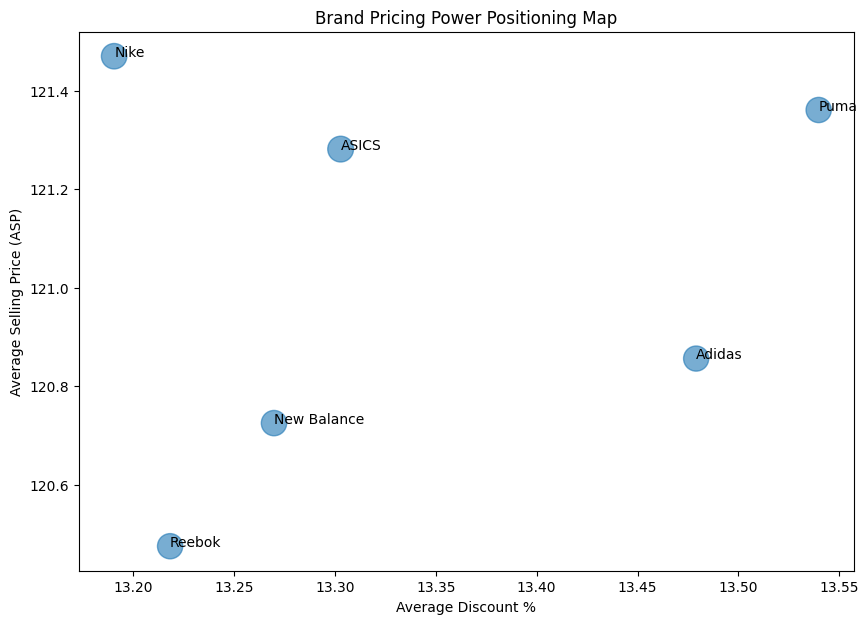

In [40]:
plt.figure(figsize=(10,7))

sizes = brand_summary["Revenue_Share_%"] * 20

plt.scatter(
    brand_summary["Avg_Discount"],
    brand_summary["Avg_ASP"],
    s=sizes,
    alpha=0.6
)

for i, row in brand_summary.iterrows():
    plt.text(row["Avg_Discount"],
             row["Avg_ASP"],
             row["brand"])

plt.xlabel("Average Discount %")
plt.ylabel("Average Selling Price (ASP)")
plt.title("Brand Pricing Power Positioning Map")

plt.show()


Top-left → Premium, strong pricing power
Bottom-right → Discount-dependent
Large bubble → Important brand

DISCOUNT DIMINISHING RETURNS
Revenue vs ASP together

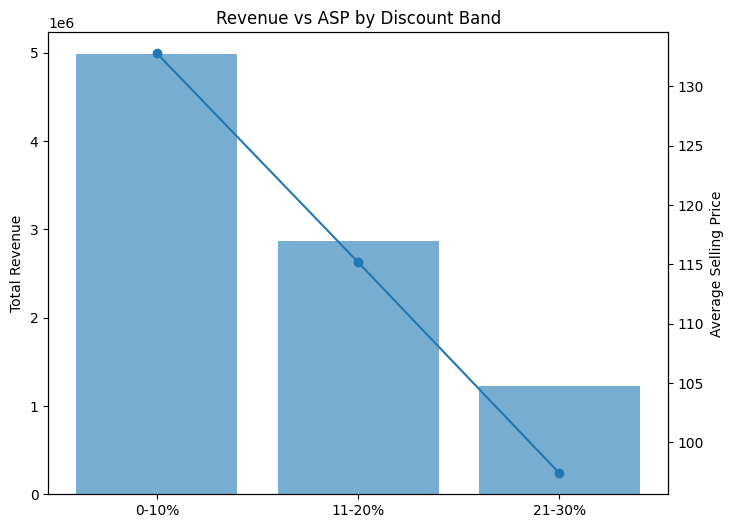

In [41]:
fig, ax1 = plt.subplots(figsize=(8,6))

ax1.bar(discount_summary["Discount_Band"],
        discount_summary["Total_Revenue"],
        alpha=0.6)

ax1.set_ylabel("Total Revenue")

ax2 = ax1.twinx()

ax2.plot(discount_summary["Discount_Band"],
         discount_summary["Avg_ASP"],
         marker="o")

ax2.set_ylabel("Average Selling Price")

plt.title("Revenue vs ASP by Discount Band")
plt.show()


Higher discounts are NOT increasing revenue proportionally.

Instead:

Revenue drops

ASP collapses

Pricing power erodes

CHANNEL EFFICIENCY SCATTER

X → Avg Discount
Y → Avg ASP

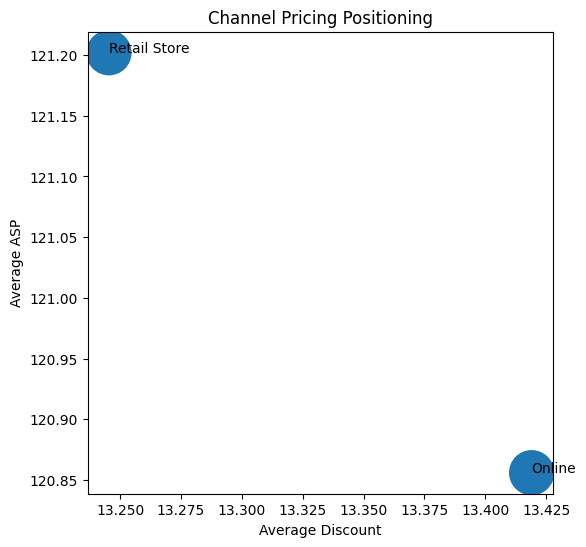

In [42]:
plt.figure(figsize=(6,6))

plt.scatter(channel_summary["Avg_Discount"],
            channel_summary["Avg_ASP"],
            s=channel_summary["Revenue_Share_%"]*20)

for i, row in channel_summary.iterrows():
    plt.text(row["Avg_Discount"],
             row["Avg_ASP"],
             row["sales_channel"])

plt.xlabel("Average Discount")
plt.ylabel("Average ASP")
plt.title("Channel Pricing Positioning")
plt.show()


COUNTRY PRIORITIZATION MATRIX
X → ASP (Premium Demand)
Y → Revenue (Market Size)

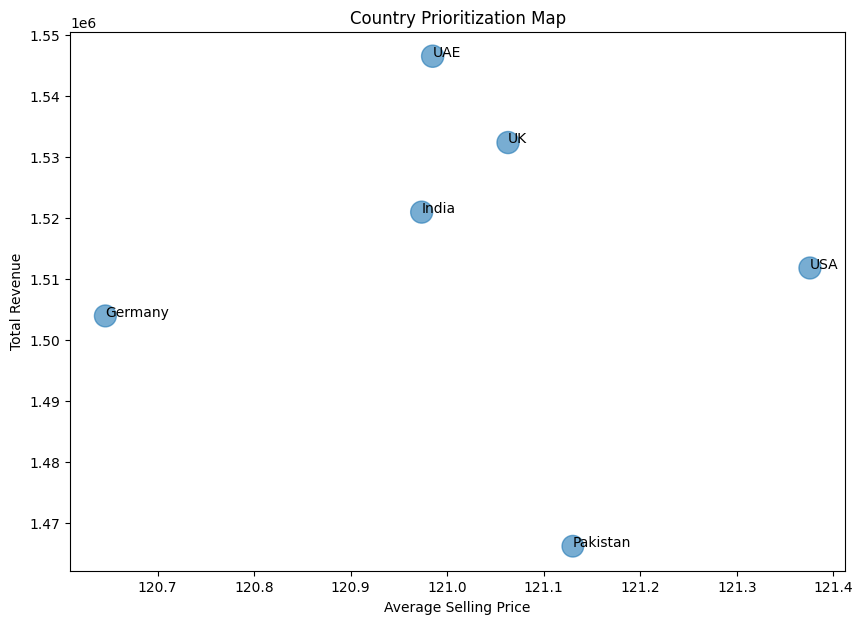

In [44]:
plt.figure(figsize=(10,7))

plt.scatter(country_summary["Avg_ASP"],
            country_summary["Total_Revenue"],
            s=country_summary["Revenue_Share_%"]*15,
            alpha=0.6)

for i, row in country_summary.iterrows():
    plt.text(row["Avg_ASP"],
             row["Total_Revenue"],
             row["country"])

plt.xlabel("Average Selling Price")
plt.ylabel("Total Revenue")
plt.title("Country Prioritization Map")

plt.show()


GROWTH MOMENTUM SLOPE

In [46]:
brand_year = df.groupby(["Year", "brand"])["revenue_usd"].sum().reset_index()

In [47]:
growth_slopes = []

for brand in brand_year["brand"].unique():
    brand_data = brand_year[brand_year["brand"] == brand]
    
    x = brand_data["Year"]
    y = brand_data["revenue_usd"]
    
    slope, intercept = np.polyfit(x, y, 1)
    
    growth_slopes.append({
        "brand": brand,
        "Growth_Slope": slope
    })

growth_slope_df = pd.DataFrame(growth_slopes)

growth_slope_df.sort_values(by="Growth_Slope", ascending=False)


,brand,Growth_Slope
5,Reebok,1054.248333
3,Nike,241.655833
2,New Balance,-150.919167
4,Puma,-436.155000
1,Adidas,-481.566667
0,ASICS,-1493.434167


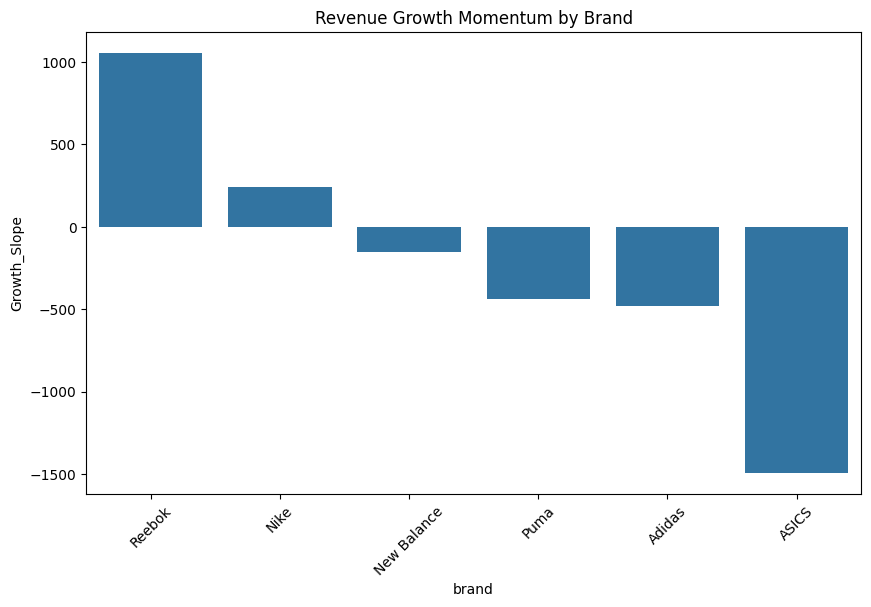

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=growth_slope_df.sort_values(by="Growth_Slope", ascending=False),
    x="brand",
    y="Growth_Slope"
)

plt.title("Revenue Growth Momentum by Brand")
plt.xticks(rotation=45)
plt.show()


In [49]:
cagr_list = []

for brand in brand_year["brand"].unique():
    brand_data = brand_year[brand_year["brand"] == brand]
    
    start_revenue = brand_data.sort_values("Year")["revenue_usd"].iloc[0]
    end_revenue = brand_data.sort_values("Year")["revenue_usd"].iloc[-1]
    
    years = brand_data["Year"].nunique() - 1
    
    cagr = ((end_revenue / start_revenue) ** (1/years) - 1) * 100
    
    cagr_list.append({
        "brand": brand,
        "CAGR_%": cagr
    })

cagr_df = pd.DataFrame(cagr_list)

cagr_df.sort_values(by="CAGR_%", ascending=False)


,brand,CAGR_%
5,Reebok,1.534461
4,Puma,0.583005
0,ASICS,-0.119953
3,Nike,-0.247133
1,Adidas,-0.442835
2,New Balance,-0.808075


FEELING MESSED UP.....
LETS DO IT AGAIN 
GETTING ON TO THE OBJECTIVES ONE BY ONE

Revenue Dependence on High Discounts

Revenue Share by Discount Band

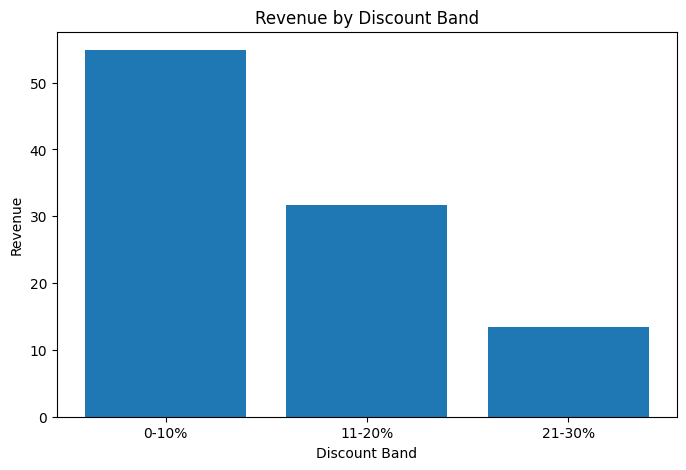

In [14]:
plt.figure(figsize=(8,5))
plt.bar(discount_summary["Discount_Band"],discount_summary["Revenue_Share_%"])
plt.title("Revenue by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Revenue")
plt.show()

Is Revenue Growth Linked to Rising Discounts?

In [16]:
yearly_metrics = df.groupby("Year").agg(
    Total_Revenue=("revenue_usd", "sum"),
    Avg_Discount=("discount_percent", "mean"),
    Avg_ASP=("ASP", "mean")
).reset_index()

yearly_metrics


,Year,Total_Revenue,Avg_Discount,Avg_ASP
0,2018,990380.20,13.366758,121.431449
1,2019,1029728.15,13.433717,120.202451
2,2020,1032345.75,13.181415,121.147307
3,2021,986065.65,13.647328,121.344534
4,2022,1026659.90,13.536763,120.948663
5,2023,1025135.90,12.839726,121.894365
6,2024,970039.25,13.389513,120.496863
7,2025,1024096.85,13.267681,120.954267
8,2026,996996.80,13.333333,120.836975


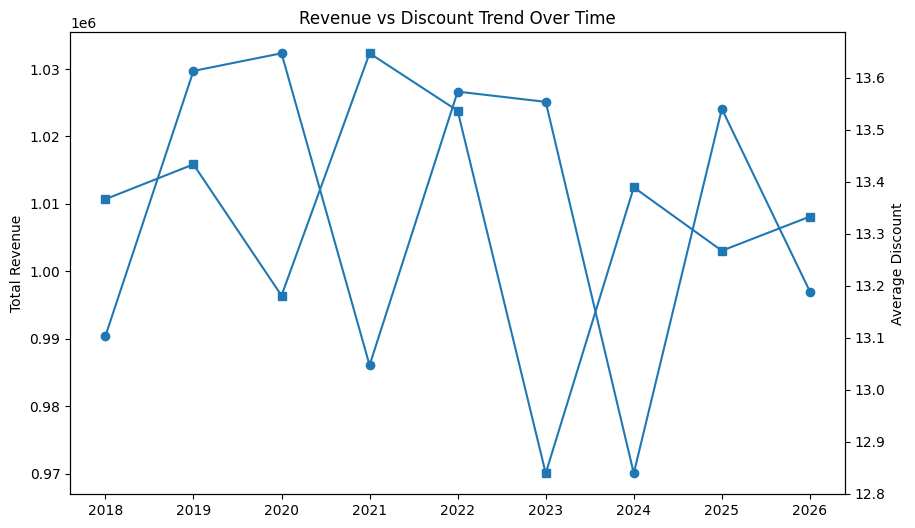

In [17]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(yearly_metrics["Year"],
         yearly_metrics["Total_Revenue"],
         marker="o")

ax1.set_ylabel("Total Revenue")

ax2 = ax1.twinx()

ax2.plot(yearly_metrics["Year"],
         yearly_metrics["Avg_Discount"],
         marker="s")

ax2.set_ylabel("Average Discount")

plt.title("Revenue vs Discount Trend Over Time")
plt.show()


In [19]:
correlation = df["discount_percent"].corr(df["revenue_usd"])

print("Correlation between Discount % and Revenue:", correlation)


Correlation between Discount % and Revenue: -0.18781778318536943


Negative → Higher discounts reduce revenue